# Quantum Support Vector Data Description (QSVDD) - Results Visualization

In [2]:
import os
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scripts.utils import get_time_elapsed, get_time_elapsed2

In [13]:
plt.style.use('default')

plt.rcParams.update({
    'axes.grid': False,
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',

    'xtick.bottom': True,
    'xtick.top': True,
    'ytick.right': True,
    'ytick.left': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.color': 'black',
    'ytick.color': 'black',

    "figure.figsize": (7.2, 4.0),
    "font.family": "serif",
    'font.size': 14,

    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'lines.linewidth': 2
})


RESULTS_DIR = os.path.join("..", "results", "training")
DATA_PATH = os.path.join("..", "data", "creditcard.csv")

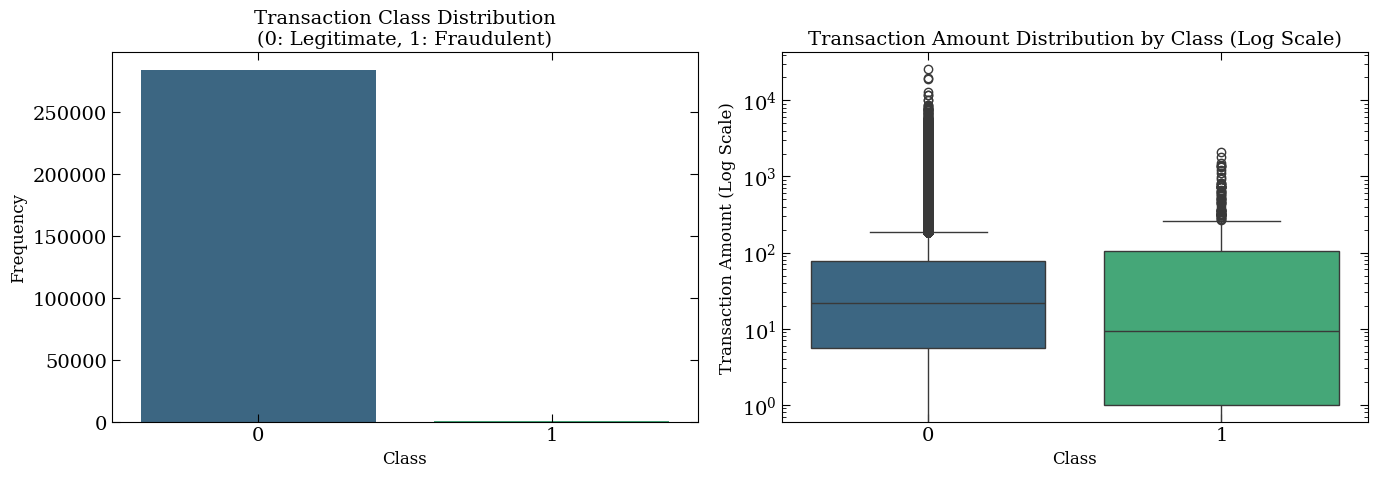

In [14]:
# Load the dataset
try:
    dataframe = pd.read_csv(DATA_PATH)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.countplot(x='Class', data=dataframe, ax=axes[0], hue='Class', legend=False, palette='viridis')
    axes[0].set_title('Transaction Class Distribution\n(0: Legitimate, 1: Fraudulent)')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Frequency')

    sns.boxplot(x='Class', y='Amount', data=dataframe, ax=axes[1], hue='Class', legend=False, palette='viridis')
    axes[1].set_yscale('log')
    axes[1].set_title('Transaction Amount Distribution by Class (Log Scale)')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Transaction Amount (Log Scale)')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Dataset not found at {DATA_PATH}. Please verify the path.")

### Functions

In [15]:
def load_data(data_type="LOSS HISTORY", ansatz_name="QCNN", batch_size=4, steps=2000, is_noisy=False):
    """
    Utility function to load any .npy file based on the project's naming convention.

    Parameters:
    - data_type (str): Type of data to load (e.g., 'LOSS HISTORY', 'PARAM HISTORY', 'EST PARAMS', 'EST PARAMS MEAN').
    - ansatz_name (str): The quantum ansatz used ('QCNN', 'QAE', 'LCQHNN').
    - batch_size (int): The batch size used during training.
    - steps (int): The number of steps used during training.
    - is_noisy (bool): Whether to load the noisy training results.
    """
    data_string = data_type.strip().replace(" ", "_").upper()

    noise_str = "_NOISE" if is_noisy else ""

    file_name = f"{ansatz_name.upper()}_B{batch_size:02d}S{steps}{noise_str}_{data_string}.npy"
    file_path = os.path.join(RESULTS_DIR, ansatz_name.upper(), file_name)

    try:
        return np.loadtxt(file_path)
    except FileNotFoundError:
        print(f"Warning: Could not locate {file_path}")
        return None

## Loss Convergence View

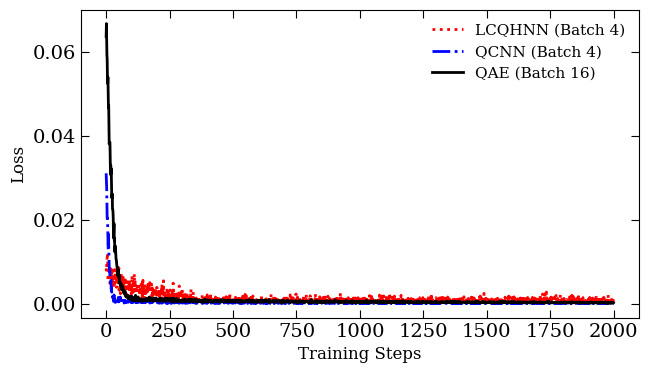

In [16]:
ansatz_list = ['lcqhnn', 'qcnn', 'qae']
batch_list = [4, 4, 16]
steps_list = [2000, 2000, 2000]

style_dict = {
    'qcnn': {'color': 'blue', 'linestyle': '-.'},
    'qae': {'color': 'black', 'linestyle': '-'},
    'lcqhnn': {'color': 'red', 'linestyle': ':'}
}

for ansatz, batch, steps in zip(ansatz_list, batch_list, steps_list):

    loss_data = load_data("LOSS HISTORY",ansatz, batch, steps, is_noisy=False)

    if loss_data is not None:
        # Fetch the specific style for this ansatz
        current_style = style_dict[ansatz]

        plt.plot(
            loss_data,
            label=f'{ansatz.upper()} (Batch {batch})',
            color=current_style['color'],
            linestyle=current_style['linestyle'],
            linewidth=2
        )

plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend(loc='best', frameon=False)
plt.savefig('../results/plots/loss_convergence.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

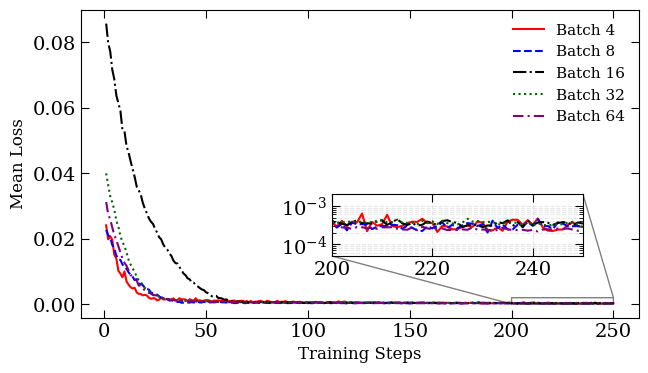

In [17]:
batch_list = [4, 8, 16, 32, 64]
colors = ['red', 'blue', 'black', 'darkgreen', 'purple']
linestyles = ['-', '--', '-.', ':', (0, (5, 2, 1, 2))]

fig, ax = plt.subplots()

axins = ax.inset_axes([0.45, 0.20, 0.45, 0.20])

for i, batch_size in enumerate(batch_list):
    f_name = f'../results/training/QCNN/QCNN_B{batch_size:02d}S250_LOSS_HISTORY_MEAN.npy'
    dat = np.loadtxt(f_name)

    mean_loss = np.mean(dat, axis=0)
    steps = range(1, len(mean_loss) + 1)

    ax.plot(
        steps,
        mean_loss,
        label=f'Batch {batch_size}',
        color=colors[i],
        linestyle=linestyles[i],
        linewidth=1.5
    )

    axins.plot(
        steps,
        mean_loss,
        color=colors[i],
        linestyle=linestyles[i],
        linewidth=1.5
    )

ax.set_xlabel('Training Steps')
ax.set_ylabel('Mean Loss')
ax.legend(loc='upper right', frameon=False)


x1, x2 = 200, 250
axins.set_xlim(x1, x2)

y_min = 0.00005
y_max = 0.002
axins.set_ylim(y_min, y_max)

axins.set_yscale('log')

axins.grid(True, which="both", alpha=0.3, linestyle='--')

ax.indicate_inset_zoom(axins, edgecolor="black", alpha=0.5)

plt.savefig('../results/plots/mean_loss_linear_with_log_zoom.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Impact of Quantum Noise on Training

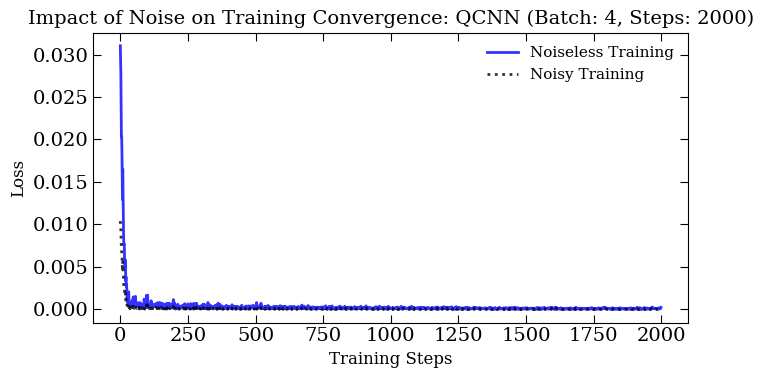

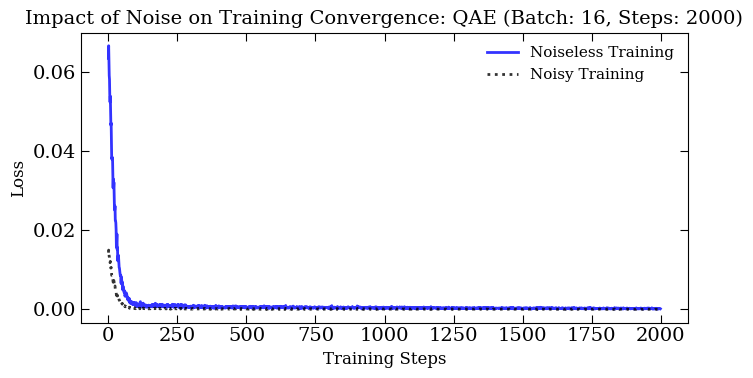

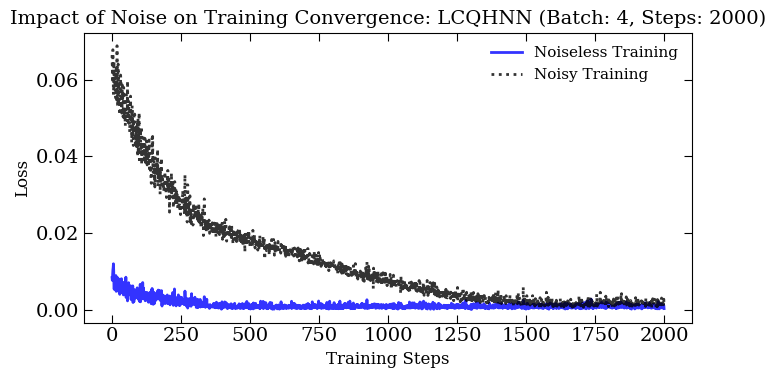

In [18]:
ansatz_list = ['qcnn', 'qae', 'lcqhnn']
batch_list = [4, 16, 4]
steps_list = [2000, 2000, 2000]

for ansatz, batch, steps in zip(ansatz_list, batch_list, steps_list):

    loss_noiseless = load_data("LOSS HISTORY", ansatz, batch, steps, is_noisy=False)
    loss_noisy = load_data("LOSS HISTORY", ansatz, batch, steps, is_noisy=True)

    if loss_noiseless is not None:
        plt.plot(loss_noiseless, label='Noiseless Training', color='blue', alpha=0.8)

    if loss_noisy is not None:
        plt.plot(loss_noisy, label='Noisy Training', color='black', alpha=0.8, linestyle=':')

    plt.xlabel('Training Steps')
    plt.ylabel('Loss')

    # Keeps the clean, box-less legend
    plt.legend(loc='best', frameon=False)

    plt.savefig(f'../results/plots/noise_impact_{ansatz}.pdf', format='pdf', bbox_inches='tight', dpi=300)


    plt.title(f'Impact of Noise on Training Convergence: {ansatz.upper()} (Batch: {batch}, Steps: {steps})')
    plt.tight_layout()
    plt.show()


## Parameter Evolution over Time

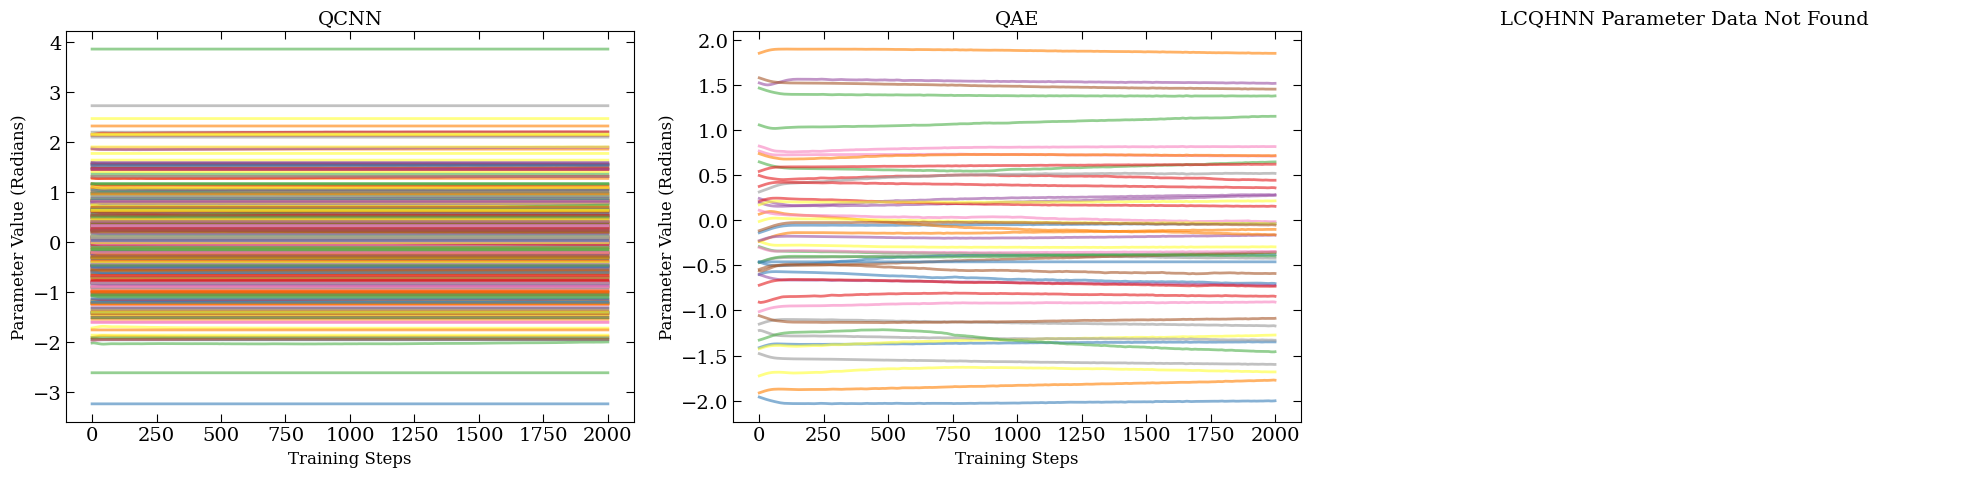

In [35]:
ansatz_configurations = [
    {'name': 'qcnn', 'batch_size': 4, 'steps': 2000},
    {'name': 'qae', 'batch_size': 4, 'steps': 2000},
    {'name': 'lcqhnn', 'batch_size': 8, 'steps': 2000}
]

loaded_data_dictionary = {}

n_configs = len(ansatz_configurations)
fig, axes = plt.subplots(1, n_configs, figsize=(20, 5))

for index, config in enumerate(ansatz_configurations):
    ansatz_type = config['name']
    training_batch = config['batch_size']
    training_steps = config['steps']
    current_axis = axes[index]

    parameter_history_array = load_data("PARAM HISTORY", ansatz_type, training_batch, training_steps)
    loaded_data_dictionary[ansatz_type] = parameter_history_array

    if parameter_history_array is not None:
        total_parameters = parameter_history_array.shape[1]
        line_colors = [cm.Set1(i % 9) for i in range(total_parameters)]

        for param_index in range(total_parameters):
            current_axis.plot(
                parameter_history_array[:, param_index],
                alpha=0.6,
                color=line_colors[param_index]
            )
        current_axis.set_title(ansatz_type.upper())
        current_axis.set_xlabel('Training Steps')
        current_axis.set_ylabel('Parameter Value (Radians)')

    else:
        current_axis.set_title(f'{ansatz_type.upper()} Parameter Data Not Found')
        current_axis.axis('off')

plt.tight_layout()
plt.savefig('../results/plots/params_convergence.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

## Cost Function Comparison

In [10]:
ansatz_configurations = [
    {'name': 'qcnn', 'batch_size': 4, 'steps': 2000},
    {'name': 'qae', 'batch_size': 16, 'steps': 2000},
    {'name': 'lcqhnn', 'batch_size': 8, 'steps': 2000}
]

## Params Means View

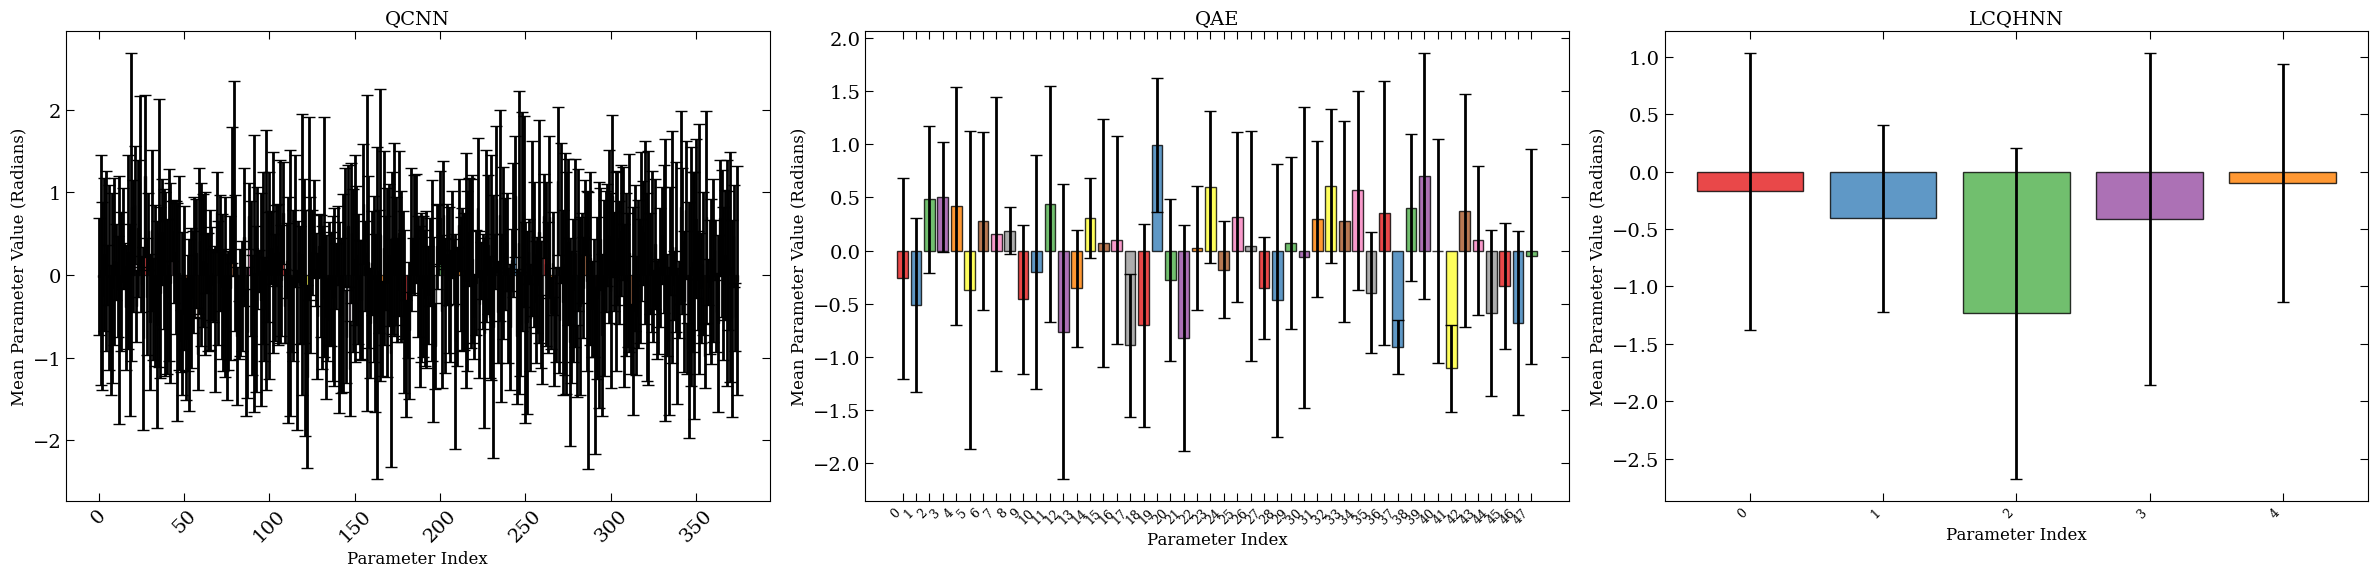

In [37]:
ansatz_configurations = [
    {'name': 'qcnn', 'batch_size': 4, 'steps': 2000},
    {'name': 'qae', 'batch_size': 16, 'steps': 2000},
    {'name': 'lcqhnn', 'batch_size': 8, 'steps': 2000}
]

n_configs = len(ansatz_configurations)
fig, axes = plt.subplots(1, n_configs, figsize=(24, 6))

for index, config in enumerate(ansatz_configurations):
    ansatz_type = config['name']
    training_batch = config['batch_size']
    training_steps = config['steps']
    current_axis = axes[index]

    estimated_parameters = load_data("EST PARAMS MEAN", ansatz_type, training_batch, training_steps)

    if estimated_parameters is not None:
        if estimated_parameters.ndim > 1:
            mean_parameters = np.mean(estimated_parameters, axis=0)
            std_parameters = np.std(estimated_parameters, axis=0)
        else:
            mean_parameters = estimated_parameters
            std_parameters = np.zeros_like(mean_parameters)

        total_parameters = len(mean_parameters)
        parameter_indices = np.arange(total_parameters)

        bar_colors = [cm.Set1(i % 9) for i in range(total_parameters)]

        current_axis.bar(
            parameter_indices,
            mean_parameters,
            yerr=std_parameters,
            color=bar_colors,
            alpha=0.8,
            capsize=4,
            edgecolor='black'
        )

        current_axis.set_title(ansatz_type.upper())
        current_axis.set_xlabel('Parameter Index')
        current_axis.set_ylabel('Mean Parameter Value (Radians)')

        if total_parameters <= 50:
            current_axis.set_xticks(parameter_indices)
            current_axis.set_xticklabels(parameter_indices, rotation=45, ha='right', fontsize=9)
        else:
            current_axis.tick_params(axis='x', rotation=45)

    else:
        current_axis.set_title(f'{ansatz_type.upper()} Estimated Parameters Data Not Found')
        current_axis.axis('off')

plt.tight_layout()
plt.savefig('../results/plots/params_mean.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

## Elapsed Time for QSVDD Using Different Parametrized Quantum Circuits

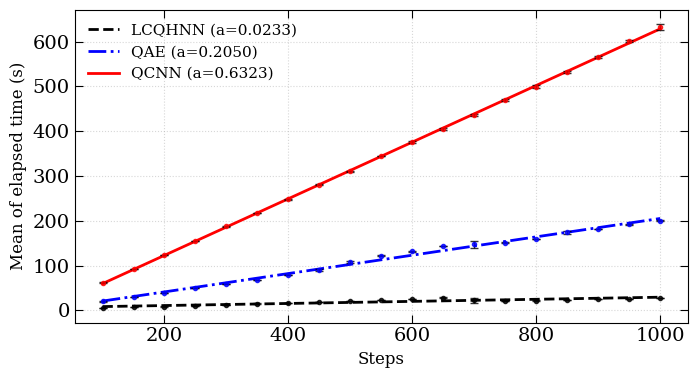

LCQHNN -> angular coefficient (a): 0.0233 | linear coefficient (b): 6.0197
QCAE   -> angular coefficient (a): 0.2050 | linear coefficient (b): 0.1641
QCNN   -> angular coefficient (a): 0.6323 | linear coefficient (b): -3.6066


In [17]:
lc_time, lc_std = get_time_elapsed('lcqhnn')
qcnn_time, qcnn_std = get_time_elapsed('qcnn')
qae_time, qae_std = get_time_elapsed('qae')
steps = np.linspace(100, 1000, 19, dtype=int)

coef_lc = np.polyfit(steps, lc_time, 1)
coef_qcnn = np.polyfit(steps, qcnn_time, 1)
coef_qae = np.polyfit(steps, qae_time, 1)

poly_lc = np.poly1d(coef_lc)
poly_qcnn = np.poly1d(coef_qcnn)
poly_qae = np.poly1d(coef_qae)

# LCQHNN
plt.errorbar(steps, lc_time, yerr=lc_std, fmt='o', color='black',
             ecolor='black', elinewidth=1, capsize=3, markersize=3, alpha=0.8, zorder=3)
plt.plot(steps, poly_lc(steps), color='black', linestyle='--',
         label=f'LCQHNN (a={coef_lc[0]:.4f})')

# QAE
plt.errorbar(steps, qae_time, yerr=qae_std, fmt='o', color='blue',
             ecolor='black', elinewidth=1, capsize=3, markersize=3, alpha=0.8, zorder=3)
plt.plot(steps, poly_qae(steps), color='blue', linestyle='-.',
         label=f'QAE (a={coef_qae[0]:.4f})')

# QCNN
plt.errorbar(steps, qcnn_time, yerr=qcnn_std, fmt='o', color='red',
             ecolor='black', elinewidth=1, capsize=3, markersize=3, alpha=0.8, zorder=3)
plt.plot(steps, poly_qcnn(steps), color='red', linestyle='-',
         label=f'QCNN (a={coef_qcnn[0]:.4f})')


plt.xlabel('Steps')
plt.ylabel('Mean of elapsed time (s)')
# plt.title('Linear Regression: Training Time Complexity')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='best', frameon=False)

plt.tight_layout()
plt.savefig('../results/plots/elapsed_time_regression.pdf', format='pdf', dpi=300)
plt.show()

a_lc, b_lc = np.polyfit(steps, lc_time, 1)
a_qae, b_qae = np.polyfit(steps, qae_time, 1)
a_qcnn, b_qcnn = np.polyfit(steps, qcnn_time, 1)

print(f"LCQHNN -> angular coefficient (a): {a_lc:.4f} | linear coefficient (b): {b_lc:.4f}")
print(f"QCAE   -> angular coefficient (a): {a_qae:.4f} | linear coefficient (b): {b_qae:.4f}")
print(f"QCNN   -> angular coefficient (a): {a_qcnn:.4f} | linear coefficient (b): {b_qcnn:.4f}")

In [10]:
steps = np.linspace(50, 450, 9, dtype=int)
steps

array([ 50, 100, 150, 200, 250, 300, 350, 400, 450])

50
100
150
200
250
300
350
400
450


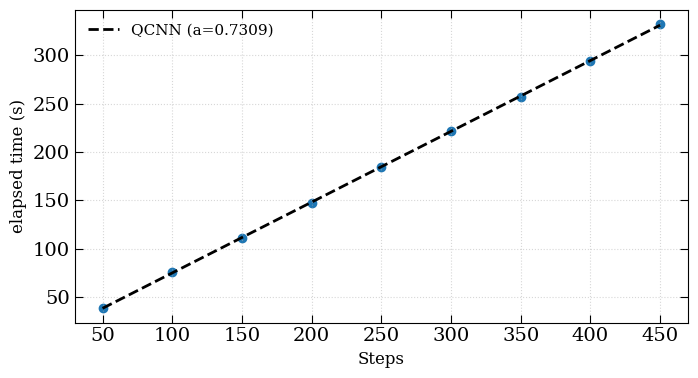

QCNN -> angular coefficient (a): 0.7309 | linear coefficient (b): 2.1263


In [11]:
lc_time = get_time_elapsed2('qcnn')
steps = np.linspace(50, 450, 9, dtype=int)

coef_lc = np.polyfit(steps, lc_time, 1)


poly_lc = np.poly1d(coef_lc)


# QCNN
plt.scatter(steps, lc_time)
plt.plot(steps, poly_lc(steps), color='black', linestyle='--',
         label=f'QCNN (a={coef_lc[0]:.4f})')



plt.xlabel('Steps')
plt.ylabel('elapsed time (s)')
# plt.title('Linear Regression: Training Time Complexity')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='best', frameon=False)

plt.tight_layout()
# plt.savefig('../results/plots/elapsed_time_regression.pdf', format='pdf', dpi=300)
plt.show()

a_lc, b_lc = np.polyfit(steps, lc_time, 1)


print(f"QCNN -> angular coefficient (a): {a_lc:.4f} | linear coefficient (b): {b_lc:.4f}")
